In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')



In [3]:
pip install seaborn


Note: you may need to restart the kernel to use updated packages.


In [9]:

sentiment_df = pd.read_csv('fear_greed_index.csv', encoding='latin1')
trades_df = pd.read_csv('historical_data.csv', encoding='latin1')

sentiment_df['date'] = pd.to_datetime(sentiment_df['date'])
trades_df['Timestamp IST'] = pd.to_datetime(trades_df['Timestamp IST'], format='mixed', dayfirst=True)
trades_df['Date'] = trades_df['Timestamp IST'].dt.floor('D')


sentiment_df.rename(columns={'date': 'Date'}, inplace=True)
df = pd.merge(trades_df, sentiment_df, on='Date', how='inner')


closed_trades = df[df['Closed PnL'] != 0].copy()
closed_trades['Is_Profitable'] = (closed_trades['Closed PnL'] > 0).astype(int)

sns.set_theme(style="whitegrid")
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']



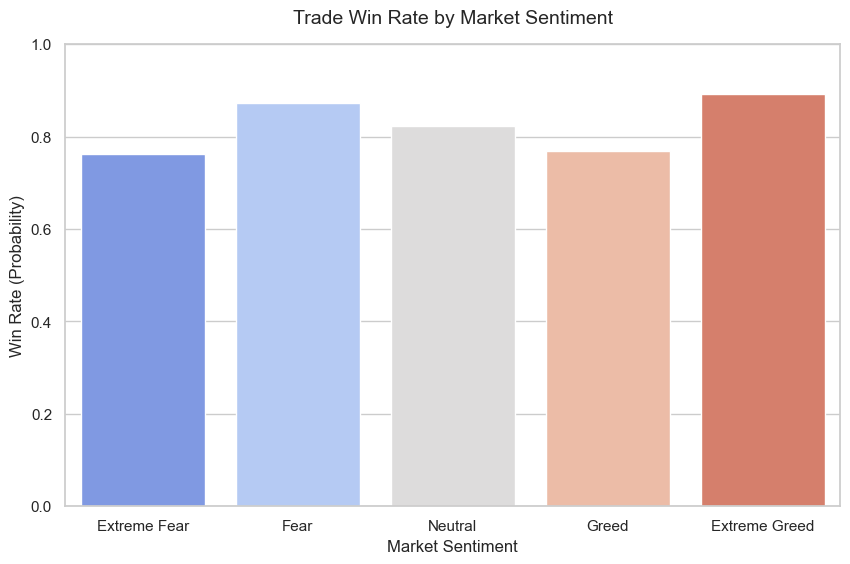

In [10]:
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Is_Profitable', data=closed_trades, order=order, errorbar=None, palette='coolwarm')
plt.title('Trade Win Rate by Market Sentiment', fontsize=14, pad=15)
plt.ylabel('Win Rate (Probability)', fontsize=12)
plt.xlabel('Market Sentiment', fontsize=12)
plt.ylim(0, 1)
plt.show()




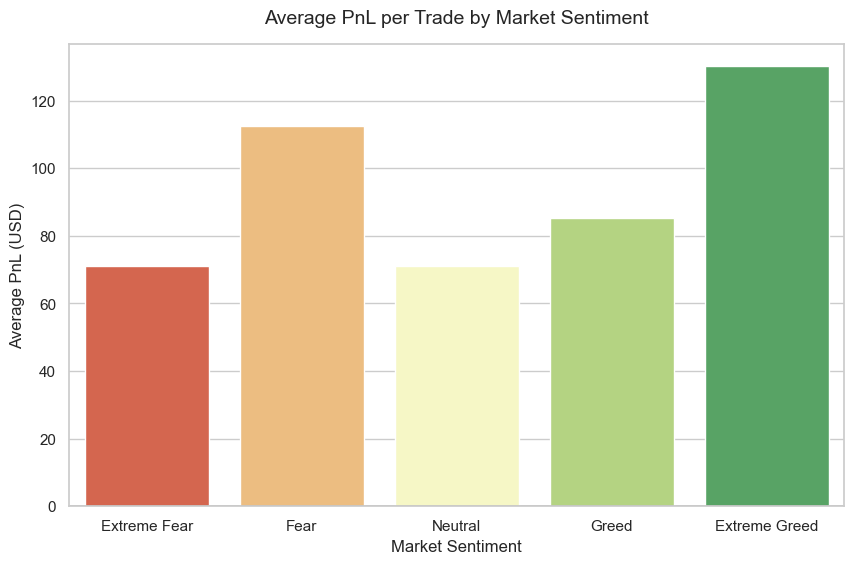

--- Win Rate by Sentiment ---
classification
Extreme Fear     0.762156
Extreme Greed    0.891670
Fear             0.872886
Greed            0.768907
Neutral          0.823889
Name: Is_Profitable, dtype: float64

--- Average PnL by Sentiment ---
classification
Extreme Fear      71.027316
Extreme Greed    130.205309
Fear             112.625988
Greed             85.403927
Neutral           71.199993
Name: Closed PnL, dtype: float64


In [11]:
plt.figure(figsize=(10, 6))
sns.barplot(x='classification', y='Closed PnL', data=closed_trades, order=order, errorbar=None, palette='RdYlGn')
plt.title('Average PnL per Trade by Market Sentiment', fontsize=14, pad=15)
plt.ylabel('Average PnL (USD)', fontsize=12)
plt.xlabel('Market Sentiment', fontsize=12)
plt.axhline(0, color='black', linewidth=1)
plt.show()


print("--- Win Rate by Sentiment ---")
print(closed_trades.groupby('classification')['Is_Profitable'].mean())
print("\n--- Average PnL by Sentiment ---")
print(closed_trades.groupby('classification')['Closed PnL'].mean())





--- Model Evaluation ---
Accuracy: 0.965135769359705


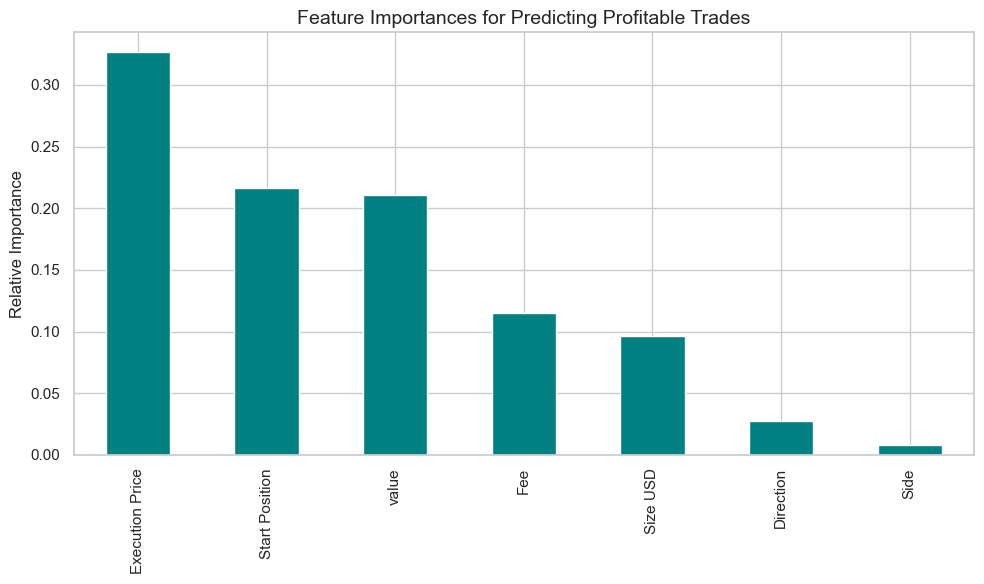


Feature Importances:
 Execution Price    0.326294
Start Position     0.216325
value              0.210976
Fee                0.114818
Size USD           0.096415
Direction          0.027410
Side               0.007760
dtype: float64


In [12]:

features = ['value', 'Size USD', 'Start Position', 'Fee', 'Execution Price']
categorical = ['Side', 'Direction']

for col in categorical:
    closed_trades[col] = closed_trades[col].astype('category').cat.codes

features.extend(categorical)
X = closed_trades[features]
y = closed_trades['Is_Profitable']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)


y_pred = rf.predict(X_test)
print("\n--- Model Evaluation ---")
print("Accuracy:", accuracy_score(y_test, y_pred))


importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
importances.plot(kind='bar', color='teal')
plt.title('Feature Importances for Predicting Profitable Trades', fontsize=14)
plt.ylabel('Relative Importance', fontsize=12)
plt.tight_layout()
plt.show()

print("\nFeature Importances:\n", importances)